In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import DenseNet121

I0000 00:00:1785305695.579134  375526 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785305696.622209  375526 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785305700.853008  375526 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
train_df = pd.read_csv("../Dataset/train_metadata.csv")
valid_df = pd.read_csv("../Dataset/valid_metadata.csv")
test_df = pd.read_csv("../Dataset/test_metadata.csv")

In [22]:
train_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
0,HAM_0005972,ISIC_0033319,nv,histo,35.0,female,lower extremity,../Dataset/HAM10000_images_part_2/ISIC_0033319...,450,600
1,HAM_0004902,ISIC_0030823,nv,follow_up,40.0,male,trunk,../Dataset/HAM10000_images_part_2/ISIC_0030823...,450,600
2,HAM_0005282,ISIC_0028730,akiec,histo,65.0,male,lower extremity,../Dataset/HAM10000_images_part_1/ISIC_0028730...,450,600
3,HAM_0000475,ISIC_0027299,nv,follow_up,40.0,male,lower extremity,../Dataset/HAM10000_images_part_1/ISIC_0027299...,450,600
4,HAM_0000949,ISIC_0032444,nv,histo,65.0,male,back,../Dataset/HAM10000_images_part_2/ISIC_0032444...,450,600
...,...,...,...,...,...,...,...,...,...,...
8007,HAM_0000940,ISIC_0032692,vasc,histo,35.0,female,lower extremity,../Dataset/HAM10000_images_part_2/ISIC_0032692...,450,600
8008,HAM_0005629,ISIC_0029317,nv,follow_up,45.0,female,upper extremity,../Dataset/HAM10000_images_part_2/ISIC_0029317...,450,600
8009,HAM_0004025,ISIC_0025983,nv,histo,20.0,female,abdomen,../Dataset/HAM10000_images_part_1/ISIC_0025983...,450,600
8010,HAM_0004542,ISIC_0027256,vasc,consensus,0.0,female,back,../Dataset/HAM10000_images_part_1/ISIC_0027256...,450,600


In [23]:
test_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
0,HAM_0006303,ISIC_0026911,nv,histo,55.0,male,abdomen,../Dataset/HAM10000_images_part_1/ISIC_0026911...,450,600
1,HAM_0002614,ISIC_0027637,nv,follow_up,75.0,male,trunk,../Dataset/HAM10000_images_part_1/ISIC_0027637...,450,600
2,HAM_0004362,ISIC_0031873,nv,follow_up,45.0,female,lower extremity,../Dataset/HAM10000_images_part_2/ISIC_0031873...,450,600
3,HAM_0006207,ISIC_0030034,mel,histo,50.0,female,back,../Dataset/HAM10000_images_part_2/ISIC_0030034...,450,600
4,HAM_0000801,ISIC_0025619,nv,histo,20.0,female,back,../Dataset/HAM10000_images_part_1/ISIC_0025619...,450,600
...,...,...,...,...,...,...,...,...,...,...
997,HAM_0006197,ISIC_0028332,nv,histo,40.0,male,back,../Dataset/HAM10000_images_part_1/ISIC_0028332...,450,600
998,HAM_0006935,ISIC_0026628,nv,follow_up,50.0,male,back,../Dataset/HAM10000_images_part_1/ISIC_0026628...,450,600
999,HAM_0004607,ISIC_0031642,mel,histo,50.0,female,back,../Dataset/HAM10000_images_part_2/ISIC_0031642...,450,600
1000,HAM_0004399,ISIC_0028905,nv,histo,20.0,female,face,../Dataset/HAM10000_images_part_1/ISIC_0028905...,450,600


In [24]:
valid_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width
0,HAM_0005031,ISIC_0025109,nv,follow_up,65.0,male,abdomen,../Dataset/HAM10000_images_part_1/ISIC_0025109...,450,600
1,HAM_0006188,ISIC_0024330,df,consensus,40.0,male,lower extremity,../Dataset/HAM10000_images_part_1/ISIC_0024330...,450,600
2,HAM_0007094,ISIC_0026785,nv,follow_up,30.0,female,lower extremity,../Dataset/HAM10000_images_part_1/ISIC_0026785...,450,600
3,HAM_0006129,ISIC_0029560,nv,histo,45.0,male,lower extremity,../Dataset/HAM10000_images_part_2/ISIC_0029560...,450,600
4,HAM_0005351,ISIC_0032590,nv,histo,20.0,female,lower extremity,../Dataset/HAM10000_images_part_2/ISIC_0032590...,450,600
...,...,...,...,...,...,...,...,...,...,...
996,HAM_0001187,ISIC_0027914,nv,follow_up,45.0,male,trunk,../Dataset/HAM10000_images_part_1/ISIC_0027914...,450,600
997,HAM_0006973,ISIC_0029377,nv,follow_up,60.0,male,trunk,../Dataset/HAM10000_images_part_2/ISIC_0029377...,450,600
998,HAM_0006723,ISIC_0026365,bkl,histo,45.0,male,lower extremity,../Dataset/HAM10000_images_part_1/ISIC_0026365...,450,600
999,HAM_0000434,ISIC_0031635,nv,follow_up,45.0,female,trunk,../Dataset/HAM10000_images_part_2/ISIC_0031635...,450,600


# Encode Label

In [4]:
label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["dx"])
valid_df["label"] = label_encoder.transform(valid_df["dx"])
test_df["label"] = label_encoder.transform(test_df["dx"])

NUM_CLASSES = len(label_encoder.classes_)

In [26]:
train_df

,lesion_id,image_id,dx,dx_type,age,sex,localization,path,Height,Width,label
0,HAM_0005972,ISIC_0033319,nv,histo,35.0,female,lower extremity,../Dataset/HAM10000_images_part_2/ISIC_0033319...,450,600,5
1,HAM_0004902,ISIC_0030823,nv,follow_up,40.0,male,trunk,../Dataset/HAM10000_images_part_2/ISIC_0030823...,450,600,5
2,HAM_0005282,ISIC_0028730,akiec,histo,65.0,male,lower extremity,../Dataset/HAM10000_images_part_1/ISIC_0028730...,450,600,0
3,HAM_0000475,ISIC_0027299,nv,follow_up,40.0,male,lower extremity,../Dataset/HAM10000_images_part_1/ISIC_0027299...,450,600,5
4,HAM_0000949,ISIC_0032444,nv,histo,65.0,male,back,../Dataset/HAM10000_images_part_2/ISIC_0032444...,450,600,5
...,...,...,...,...,...,...,...,...,...,...,...
8007,HAM_0000940,ISIC_0032692,vasc,histo,35.0,female,lower extremity,../Dataset/HAM10000_images_part_2/ISIC_0032692...,450,600,6
8008,HAM_0005629,ISIC_0029317,nv,follow_up,45.0,female,upper extremity,../Dataset/HAM10000_images_part_2/ISIC_0029317...,450,600,5
8009,HAM_0004025,ISIC_0025983,nv,histo,20.0,female,abdomen,../Dataset/HAM10000_images_part_1/ISIC_0025983...,450,600,5
8010,HAM_0004542,ISIC_0027256,vasc,consensus,0.0,female,back,../Dataset/HAM10000_images_part_1/ISIC_0027256...,450,600,6


## Compute Class Weights

In [5]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.368593238822246), 1: np.float64(2.7848453249913105), 2: np.float64(1.3021290427433772), 3: np.float64(12.440993788819876), 4: np.float64(1.2860353130016051), 5: np.float64(0.21338020666879728), 6: np.float64(10.040100250626567)}


In [28]:
class_weights

{0: np.float64(4.368593238822246),
 1: np.float64(2.7848453249913105),
 2: np.float64(1.3021290427433772),
 3: np.float64(12.440993788819876),
 4: np.float64(1.2860353130016051),
 5: np.float64(0.21338020666879728),
 6: np.float64(10.040100250626567)}

## Create Image Loader

In [6]:
IMG_SIZE = (224, 224)

def process_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)

    return image, label

## Create TensorFlow Dataset

# Data Augumentation

In [7]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.RandomContrast(0.2),

    tf.keras.layers.RandomBrightness(0.2)

])

E0000 00:00:1785305726.793214  375526 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
image_1 = "../Dataset/HAM10000_images_part_1/ISIC_0024306.jpg"
label = 2

test = process_image(image_1,label)

data = lambda x, y: (data_augmentation(x, training=True), y)

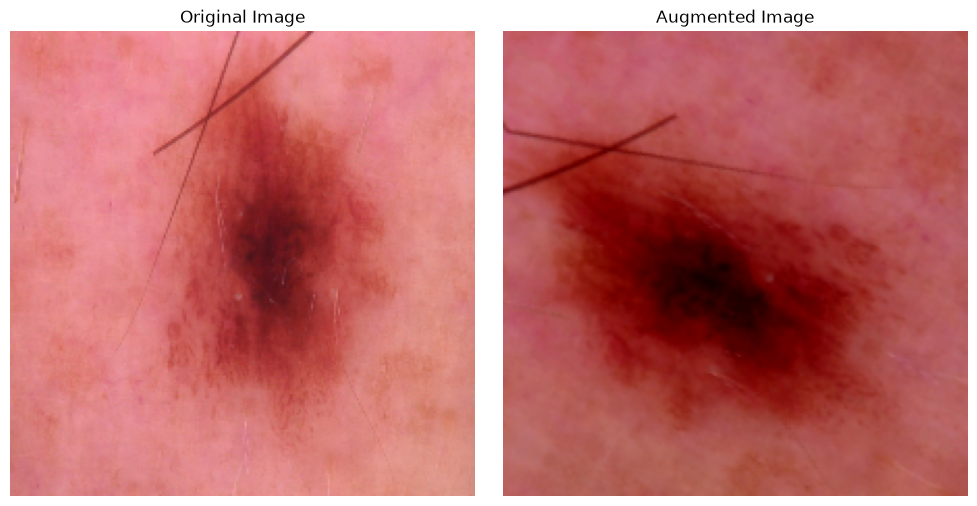

In [9]:
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Define the Data Augmentation Pipeline
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomBrightness(0.2),
    ]
)

IMG_SIZE = (224, 224)


# 2. Define Image Loading and Preprocessing Function
def process_image(path, label):
    # Read the raw file bytes from disk
    image = tf.io.read_file(path)
    # Decode the JPEG into an image tensor (uint8)
    image = tf.image.decode_jpeg(image, channels=3)
    # Resize image to target dimensions
    image = tf.image.resize(image, IMG_SIZE)
    return image, label


# 3. Setup File Variables
image_1 = "../Dataset/HAM10000_images_part_1/ISIC_0024306.jpg"
label = 2

# 4. Load the Image Data
test_image, test_label = process_image(image_1, label)

# 5. Define Lambda Function for Augmentation
# Keras layers require batch dimension, so x must be 4D: [batch, H, W, C]
data = lambda x, y: (data_augmentation(x, training=True), y)

# 6. Prepare and Run Augmentation
# Add a batch dimension: changes shape from (224, 224, 3) to (1, 224, 224, 3)
batch_image = tf.expand_dims(test_image, axis=0)

# Pass the batched image into your lambda function
augmented_batch, _ = data(batch_image, test_label)

# Remove the batch dimension to return to 3D image shape: (224, 224, 3)
# Squeeze takes the 4D tensor and removes the dimension of size 1
augmented_image = tf.squeeze(augmented_batch, axis=0)

# 7. Visualize Original vs. Augmented Image Side-by-Side
plt.figure(figsize=(10, 5))

# Display Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
# Cast back to uint8 integers so matplotlib renders pixel ranges (0-255) correctly
plt.imshow(tf.cast(test_image, tf.uint8))
plt.axis("off")

# Display Augmented Image
plt.subplot(1, 2, 2)
plt.title("Augmented Image")
plt.imshow(tf.cast(augmented_image, tf.uint8))
plt.axis("off")

# Show the plot window
plt.tight_layout()
plt.show()


In [33]:
type(test)

tuple

In [34]:
data

<function __main__.<lambda>(x, y)>

In [35]:
test

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[221.69356 , 129.92642 , 125.40713 ],
         [224.76985 , 130.94165 , 130.0177  ],
         [225.99107 , 129.28667 , 134.49211 ],
         ...,
         [224.70813 , 131.90092 , 129.77856 ],
         [225.19437 , 132.70776 , 131.71681 ],
         [225.15178 , 135.8393  , 136.4866  ]],
 
        [[226.72273 , 130.97536 , 129.05803 ],
         [229.00894 , 131.54912 , 134.03572 ],
         [229.67595 , 134.4866  , 138.542   ],
         ...,
         [220.70454 , 134.09378 , 128.46509 ],
         [222.48756 , 134.99557 , 130.25293 ],
         [225.70734 , 135.5691  , 131.27644 ]],
 
        [[228.31512 , 130.89293 , 128.      ],
         [225.97847 , 130.24896 , 130.91963 ],
         [227.2233  , 132.00032 , 134.87532 ],
         ...,
         [226.83069 , 136.59387 , 132.51355 ],
         [225.00159 , 135.54544 , 132.43753 ],
         [224.68576 , 135.71606 , 134.04738 ]],
 
        ...,
 
        [[206.60359 , 118.51423 

## Create TensorFlow Dataset

In [36]:
# train_dataset = tf.data.Dataset.from_tensor_slices(
#     (train_df["path"], train_df["label"])
# )

# train_dataset = train_dataset.map(
#     process_image,
#     num_parallel_calls=tf.data.AUTOTUNE
# )

# train_dataset = train_dataset.map(
#     lambda x, y: (data_augmentation(x, training=True), y),
#     num_parallel_calls=tf.data.AUTOTUNE
# )

# train_dataset = train_dataset.shuffle(
#     buffer_size=len(train_df),
#     reshuffle_each_iteration=True
# )

# valid_dataset = tf.data.Dataset.from_tensor_slices(
#     (valid_df["path"], valid_df["label"])
# )

# valid_dataset = valid_dataset.map(
#     process_image,
#     num_parallel_calls=tf.data.AUTOTUNE
# )

# test_dataset = tf.data.Dataset.from_tensor_slices(
#     (test_df["path"], test_df["label"])
# )

# test_dataset = test_dataset.map(
#     process_image,
#     num_parallel_calls=tf.data.AUTOTUNE
# )

In [10]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["path"], train_df["label"])
)

train_dataset = train_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
train_dataset = train_dataset.batch(32)
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

 #   Validation

In [11]:
valid_dataset = tf.data.Dataset.from_tensor_slices(
    (valid_df["path"], valid_df["label"])
)

valid_dataset = valid_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Test



In [12]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_df["path"], test_df["label"])
)

test_dataset = test_dataset.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [13]:
BATCH_SIZE = 32

valid_dataset = valid_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

In [51]:
valid_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, None), dtype=tf.int64, name=None))>

In [12]:
basic_cnn = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224,224,3)),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

In [14]:
basic_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,295 (91.20 MB)

 Trainable params: 23,908,295 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.optimizers import Adam

In [ ]:
basic_cnn.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [ ]:
history_basic = basic_cnn.fit(

    train_dataset,

    validation_data=valid_dataset,

    epochs=5,

    class_weight=class_weights,

    verbose=1

)

Epoch 1/5


/home/aximsoft/snap/code/253/.local/share/virtualenvs/Skin_Disease_Classification___Diagnosis_Pl-WW3Rx1qq/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


251/251 ━━━━━━━━━━━━━━━━━━━━ 629s 2s/step - accuracy: 0.1171 - loss: 1.9147 - val_accuracy: 0.0400 - val_loss: 1.9595
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 594s 2s/step - accuracy: 0.1480 - loss: 1.9211 - val_accuracy: 0.0360 - val_loss: 1.9681
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 661s 3s/step - accuracy: 0.1503 - loss: 1.8979 - val_accuracy: 0.0549 - val_loss: 1.9669
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 612s 2s/step - accuracy: 0.0801 - loss: 1.9450 - val_accuracy: 0.0390 - val_loss: 1.9736
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 635s 3s/step - accuracy: 0.1291 - loss: 1.8882 - val_accuracy: 0.0609 - val_loss: 1.9718


In [ ]:
import pickle

with open("basic_cnn_history.pkl", "wb") as file:
    pickle.dump(history_basic.history, file)

print("Training history saved.")

Training history saved.


In [63]:


deep_cnn = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(224,224,3)
    ),


    # Block 1
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),



    # Block 2
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),



    # Block 3
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),



    tf.keras.layers.Flatten(),


    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),


    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])



In [64]:
deep_cnn.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [65]:
history_deep = deep_cnn.fit(

    train_dataset,

    validation_data=valid_dataset,

    epochs=5,

    class_weight=class_weights,

    verbose=1

)

Epoch 1/5


/home/aximsoft/snap/code/253/.local/share/virtualenvs/Skin_Disease_Classification___Diagnosis_Pl-WW3Rx1qq/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


251/251 ━━━━━━━━━━━━━━━━━━━━ 2141s 8s/step - accuracy: 0.3655 - loss: 3.4036 - val_accuracy: 0.2877 - val_loss: 2.0989
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1738s 7s/step - accuracy: 0.4135 - loss: 1.6733 - val_accuracy: 0.3167 - val_loss: 1.6289
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1658s 7s/step - accuracy: 0.4393 - loss: 1.6037 - val_accuracy: 0.5694 - val_loss: 1.2701
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1689s 7s/step - accuracy: 0.4561 - loss: 1.5599 - val_accuracy: 0.1688 - val_loss: 2.1705
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1679s 7s/step - accuracy: 0.4688 - loss: 1.5767 - val_accuracy: 0.5754 - val_loss: 1.2207


In [69]:
import pickle
with open("history_deep_history.pkl", "wb") as file:
    pickle.dump(history_deep.history, file)

print("Training history saved.")

Training history saved.


# CNN + Batch Normalization

# The accuracy is low for Initial model developement

In [ ]:

cnn_bn =tf.keras.Sequential([


    tf.keras.layers.Input(
        shape=(224,224,3)
    ),


    tf.keras.layers.Conv2D(
        32,
        3
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Activation("relu"),


    tf.keras.layers.Conv2D(
        64,
        3
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Activation("relu"),


    tf.keras.layers.MaxPooling2D(),


    tf.keras.layers.Flatten(),


    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),


    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])



In [20]:
cnn_bn.compile(

optimizer=Adam(learning_rate=0.0001),

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)


history_bn=cnn_bn.fit(

train_dataset,

validation_data=valid_dataset,

epochs=5,

class_weight=class_weights

)

Epoch 1/5


251/251 ━━━━━━━━━━━━━━━━━━━━ 2416s 10s/step - accuracy: 0.0306 - loss: 1.9460 - val_accuracy: 0.0330 - val_loss: 1.9524
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 6797s 27s/step - accuracy: 0.0236 - loss: 1.9460 - val_accuracy: 0.0140 - val_loss: 1.9522
Epoch 3/5
 47/251 ━━━━━━━━━━━━━━━━━━━━ 29:52 9s/step - accuracy: 0.0113 - loss: 1.9052

KeyboardInterrupt: 

In [24]:
print(len(train_df))
print(len(valid_df))
print(len(test_df))

print(train_df["dx"].value_counts())

print(label_encoder.classes_)
print(train_df[["dx", "label"]].head(10))

print(train_df["path"].head())

8012
1001
1002
dx
nv       5364
mel       890
bkl       879
bcc       411
akiec     262
vasc      114
df         92
Name: count, dtype: int64
['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']
      dx  label
0     nv      5
1     nv      5
2  akiec      0
3     nv      5
4     nv      5
5     nv      5
6    bkl      2
7    bkl      2
8     nv      5
9  akiec      0
0    ../Dataset/HAM10000_images_part_2/ISIC_0033319...
1    ../Dataset/HAM10000_images_part_2/ISIC_0030823...
2    ../Dataset/HAM10000_images_part_1/ISIC_0028730...
3    ../Dataset/HAM10000_images_part_1/ISIC_0027299...
4    ../Dataset/HAM10000_images_part_2/ISIC_0032444...
Name: path, dtype: str


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [44.089355..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [18.06007..248.94623].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [31.199055..208.60416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [18.956055..236.37822].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [58.487827..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..199.44356].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [60.345398..236.0835].
Clipping

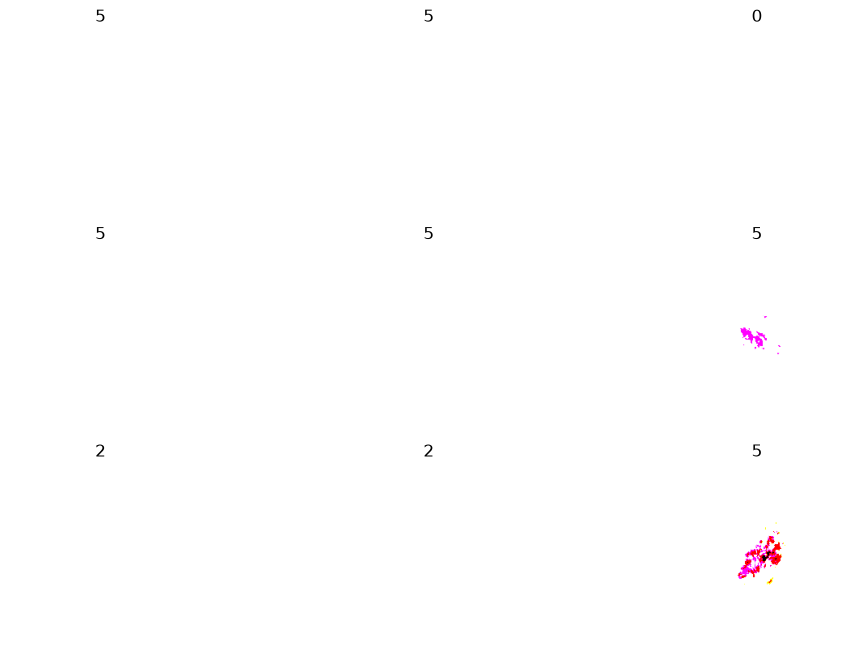

In [25]:
images, labels = next(iter(train_dataset))

plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(int(labels[i]))
    plt.axis("off")

plt.show()

In [35]:
print("Missing paths:", train_df["path"].isna().sum())

Missing paths: 0


In [ ]:
train_dataset_bn = tf.data.Dataset.from_tensor_slices(
    (train_df["path"], train_df["label"])
)

train_dataset_bn = train_dataset_bn.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset_bn = train_dataset_bn.shuffle(1000)
train_dataset_bn = train_dataset_bn.batch(32)
train_dataset_bn = train_dataset_bn.prefetch(tf.data.AUTOTUNE)

In [ ]:

cnn_bn =tf.keras.Sequential([


    tf.keras.layers.Input(
        shape=(224,224,3)
    ),


    tf.keras.layers.Conv2D(
        32,
        (3,3)
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Activation("relu"),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        64,
        (3,3)
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Activation("relu"),


    tf.keras.layers.MaxPooling2D(2,2),


    tf.keras.layers.Flatten(),


    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),


    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

cnn_bn.compile(

optimizer=Adam(learning_rate=0.0001),

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)


history_bn=cnn_bn.fit(

train_dataset_bn,

validation_data=valid_dataset,

epochs=5,

class_weight=class_weights

)

Epoch 1/5


/home/aximsoft/snap/code/253/.local/share/virtualenvs/Skin_Disease_Classification___Diagnosis_Pl-WW3Rx1qq/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1785300094.904488  234167 shuffle_dataset_op.cc:453] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 3370 of 8012
I0000 00:00:1785300109.071803  234167 shuffle_dataset_op.cc:483] Shuffle buffer filled.


251/251 ━━━━━━━━━━━━━━━━━━━━ 1024s 4s/step - accuracy: 0.4104 - loss: 2.5633 - val_accuracy: 0.4705 - val_loss: 1.3858
Epoch 2/5


I0000 00:00:1785301116.033011  265278 shuffle_dataset_op.cc:453] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 2449 of 8012
I0000 00:00:1785301136.027207  265278 shuffle_dataset_op.cc:453] ShuffleDatasetV3:25: Filling up shuffle buffer (this may take a while): 6927 of 8012


In [ ]:

cnn_bn =tf.keras.Sequential([


    tf.keras.layers.Input(
        shape=(224,224,3)
    ),


    tf.keras.layers.Conv2D(
        32,
        (3,3)
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Activation("relu"),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        64,
        (3,3)
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Activation("relu"),


    tf.keras.layers.MaxPooling2D(2,2),


    tf.keras.layers.Flatten(),


    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),


    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

cnn_bn.compile(

optimizer=Adam(learning_rate=0.0001),

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)


history_bn=cnn_bn.fit(

train_dataset_bn,

validation_data=valid_dataset,

epochs=5,

class_weight=class_weights

)

Epoch 1/5


/home/aximsoft/snap/code/253/.local/share/virtualenvs/Skin_Disease_Classification___Diagnosis_Pl-WW3Rx1qq/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1785301489.474689  282615 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 2806 of 8012
I0000 00:00:1785301499.481036  282615 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 5736 of 8012
I0000 00:00:1785301507.305615  282615 shuffle_dataset_op.cc:483] Shuffle buffer filled.


251/251 ━━━━━━━━━━━━━━━━━━━━ 1011s 4s/step - accuracy: 0.1980 - loss: 2.6608 - val_accuracy: 0.2048 - val_loss: 1.6843
Epoch 2/5


I0000 00:00:1785302531.404868  298034 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 2413 of 8012
I0000 00:00:1785302551.409424  298034 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 7893 of 8012
I0000 00:00:1785302551.808040  298034 shuffle_dataset_op.cc:483] Shuffle buffer filled.


251/251 ━━━━━━━━━━━━━━━━━━━━ 1042s 4s/step - accuracy: 0.3424 - loss: 1.8283 - val_accuracy: 0.3856 - val_loss: 1.4663
Epoch 3/5


I0000 00:00:1785303539.991770  328908 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 2501 of 8012
I0000 00:00:1785303549.993008  328908 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 4869 of 8012
I0000 00:00:1785303559.999961  328908 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 6736 of 8012
I0000 00:00:1785303567.421305  328908 shuffle_dataset_op.cc:483] Shuffle buffer filled.


251/251 ━━━━━━━━━━━━━━━━━━━━ 1016s 4s/step - accuracy: 0.3783 - loss: 1.7666 - val_accuracy: 0.1179 - val_loss: 1.7388
Epoch 4/5


I0000 00:00:1785304556.011772  359011 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 2965 of 8012
I0000 00:00:1785304566.012780  359011 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 6244 of 8012
I0000 00:00:1785304571.715879  359011 shuffle_dataset_op.cc:483] Shuffle buffer filled.


251/251 ━━━━━━━━━━━━━━━━━━━━ 877s 3s/step - accuracy: 0.1282 - loss: 1.8076 - val_accuracy: 0.1309 - val_loss: 1.5804
Epoch 5/5


I0000 00:00:1785305433.576711  373968 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 2619 of 8012
I0000 00:00:1785305443.578603  373968 shuffle_dataset_op.cc:453] ShuffleDatasetV3:20: Filling up shuffle buffer (this may take a while): 4841 of 8012


In [ ]:
import pickle

with open("history_bn_history.pkl", "wb") as file:
    pickle.dump(history_bn.history, file)

print("Training history saved.")

# CNN + Dropout

In [ ]:
cnn_dp=tf.keras.Sequential([


    tf.keras.layers.Input(
        shape=(224,224,3)
    ),


    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu"
),

    tf.keras.layers.MaxPooling2D(2,2),



    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
            128,
            (3,3),
            activation="relu"
        ),
    
        tf.keras.layers.MaxPooling2D(2,2),


    tf.keras.layers.Flatten(),


    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),


    tf.keras.layers.Dropout(0.5),


    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])


In [17]:
cnn_dp.compile(

optimizer="adam",

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)


cnn_dp =cnn_dp.fit(

train_dataset,

validation_data=valid_dataset,

epochs=5,

class_weight=class_weights

)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 702s 3s/step - accuracy: 0.1261 - loss: 28.8779 - val_accuracy: 0.0589 - val_loss: 1.9840
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 706s 3s/step - accuracy: 0.0713 - loss: 1.9688 - val_accuracy: 0.1109 - val_loss: 1.9856
Epoch 3/5
  4/251 ━━━━━━━━━━━━━━━━━━━━ 10:42 3s/step - accuracy: 0.0781 - loss: 1.4395

KeyboardInterrupt: 

In [18]:
cnn_dp=tf.keras.Sequential([


    tf.keras.layers.Input(
        shape=(224,224,3)
    ),


    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu"
),

    tf.keras.layers.MaxPooling2D(2,2),



    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
            128,
            (3,3),
            activation="relu"
        ),
    
        tf.keras.layers.MaxPooling2D(2,2),


    tf.keras.layers.Flatten(),


    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),


    tf.keras.layers.Dropout(0.5),


    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

])

cnn_dp.compile(

optimizer=Adam(learning_rate=0.0001),

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)


cnn_dp =cnn_dp.fit(

train_dataset,

validation_data=valid_dataset,

epochs=5,

class_weight=class_weights

)

Epoch 1/5


/home/aximsoft/snap/code/253/.local/share/virtualenvs/Skin_Disease_Classification___Diagnosis_Pl-WW3Rx1qq/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


251/251 ━━━━━━━━━━━━━━━━━━━━ 773s 3s/step - accuracy: 0.1559 - loss: 7.7362 - val_accuracy: 0.0549 - val_loss: 1.9266
Epoch 2/5
168/251 ━━━━━━━━━━━━━━━━━━━━ 4:22 3s/step - accuracy: 0.0759 - loss: 1.9398

KeyboardInterrupt: 

In [ ]:
import pickle

with open("cnn_dp_history.pkl", "wb") as file:
    pickle.dump(cnn_dp.history, file)

print("Training history saved.")

# Transfer Learning Techniques

# common function for model

In [ ]:
def build_transfer_model(base_model):


    base_model.trainable=False


    model=tf.keras.Sequential([


        base_model,


        tf.keras.layers.GlobalAveragePooling2D(),


        tf.keras.layers.Dense(
            256,
            activation="relu"
        ),


        tf.keras.layers.Dropout(0.5),


        tf.keras.layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )

    ])


    return model

In [ ]:
mobilenet_base=tf.keras.applications.MobileNetV2(

    input_shape=(224,224,3),

    include_top=False,

    weights="imagenet"

)


mobilenet_model=build_transfer_model(
    mobilenet_base
)

# compile

mobilenet_model.compile(

optimizer="adam",

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

# Train

history_mobile= mobilenet_model.fit(

train_dataset,

validation_data=valid_dataset,

epochs=5,

class_weight=class_weights

)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


NameError: name 'build_transfer_model' is not defined

In [ ]:
import pickle

with open("history_mobile_history.pkl", "wb") as file:
    pickle.dump(history_mobile.history, file)

print("Training history saved.")

# EfficientNetB0

In [ ]:
efficient_base=tf.keras.applications.EfficientNetB0(

input_shape=(224,224,3),

include_top=False,

weights="imagenet"

)


efficient_model=build_transfer_model(
    efficient_base
)

# compile

efficient_model.compile(

optimizer="adam",

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

# Train

history_efficient= efficient_model.fit(

train_dataset,

validation_data=valid_dataset,

epochs=30,

class_weight=class_weights

)

In [ ]:
import pickle

with open("history_efficient_history.pkl", "wb") as file:
    pickle.dump(history_efficient.history, file)

print("Training history saved.")

# ResNet50

In [ ]:
resnet_base=tf.keras.applications.ResNet50(

input_shape=(224,224,3),

include_top=False,

weights="imagenet"

)


resnet_model=build_transfer_model(
    resnet_base
)

# compile

resnet_model.compile(

optimizer="adam",

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

# Train

history_resnet= resnet_model.fit(

train_dataset,

validation_data=valid_dataset,

epochs=30,

class_weight=class_weights

)

In [ ]:
import pickle

with open("history_resnet_history.pkl", "wb") as file:
    pickle.dump(history_resnet.history, file)

print("Training history saved.")

# DenseNet121

In [ ]:
dense_base=tf.keras.applications.DenseNet121(

input_shape=(224,224,3),

include_top=False,

weights="imagenet"

)


densenet_model=build_transfer_model(
    dense_base
)

# compile

densenet_model.compile(

optimizer="adam",

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

# Train

history_densenet= densenet_model.fit(

train_dataset,

validation_data=valid_dataset,

epochs=30,

class_weight=class_weights

)

In [ ]:
import pickle

with open("history_densenet_history.pkl", "wb") as file:
    pickle.dump(history_densenet.history, file)

print("Training history saved.")